# 05 — Churn Logistic Regression

This notebook builds the first machine-learning churn model. Logistic regression is a strong first model because it produces churn probabilities, is fast, and is easier to explain than most complex models.

The model uses a **180-day observation window** to predict whether an eligible customer will make no retained purchase in the **next 90 days**. All choices are made on historical validation months before the final September 2011 test is opened.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.calibration import calibration_curve
from sklearn.metrics import ConfusionMatrixDisplay, brier_score_loss

# Make package imports work whether Jupyter starts in the repo root or notebooks/.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from customer_intelligence.churn.baseline import baseline_metrics, recency_rule
from customer_intelligence.churn.modeling import (
    build_logistic_pipeline, coefficient_table,
    make_logistic_feature_contract, rolling_logistic_validation,
    tune_probability_threshold,
)
from customer_intelligence.churn.validation import (
    final_temporal_holdout, purged_rolling_splits,
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

## 1. Load the frozen training table

Each row represents one customer at one monthly snapshot. Every feature contains only information available on or before that snapshot. `Churn = 1` means the customer made no retained purchase during the following 90 days.

In [2]:
data_path = PROJECT_ROOT / 'data' / 'processed' / 'churn_training_table.csv'
churn_data = pd.read_csv(data_path, parse_dates=['SnapshotDate'])

print(f'Rows: {len(churn_data):,}')
print(f'Customers: {churn_data["Customer ID"].nunique():,}')
print(f'Snapshots: {churn_data["SnapshotDate"].nunique()}')
print(f'Overall churn prevalence: {churn_data["Churn"].mean():.1%}')

Rows: 47,821
Customers: 5,204
Snapshots: 16
Overall churn prevalence: 50.9%


## 2. Define exactly what the model may see

Customer ID is an identifier, not behaviour. Snapshot date identifies timing, and the churn label is the answer. None enters the model. Future-looking fields are explicitly rejected. Numeric values are median-imputed and standardized inside each training fold; month is one-hot encoded. Keeping preprocessing inside the pipeline prevents validation information from leaking into training.

In [3]:
feature_contract = make_logistic_feature_contract(churn_data)
print(f'Numeric predictors: {len(feature_contract.numeric_features)}')
print(f'Categorical predictors: {feature_contract.categorical_features}')
print('Excluded from modelling: Customer ID, SnapshotDate, Churn, redundant calendar fields')

Numeric predictors: 40
Categorical predictors: ('SnapshotMonth',)
Excluded from modelling: Customer ID, SnapshotDate, Churn, redundant calendar fields


## 3. Create chronological validation folds

We train on older snapshots and validate on later ones. A 90-day purge gap ensures every training label would already have been known when the validation prediction was made. This imitates production more honestly than randomly mixing past and future rows.

In [4]:
validation_dates = pd.to_datetime([
    '2011-02-01', '2011-03-01', '2011-04-01', '2011-05-01'
])
folds = purged_rolling_splits(
    churn_data, validation_dates=validation_dates, horizon_days=90
)
pd.DataFrame({
    'Validation month': [fold.validation_date for fold in folds],
    'Training rows': [len(fold.train_indices) for fold in folds],
    'Validation rows': [len(fold.validation_indices) for fold in folds],
})

,Validation month,Training rows,Validation rows
0,2011-02-01,17072,3337
1,2011-03-01,20525,3330
2,2011-04-01,23917,3292
3,2011-05-01,23917,3043


## 4. Select regularization strength

`C` controls model complexity: smaller values shrink coefficients more strongly. We choose the value with the best average validation PR-AUC, with probability accuracy and lift used as tie-breakers. The September test is not involved.

In [5]:
selected_c, c_results, validation_predictions = rolling_logistic_validation(
    churn_data, folds,
    c_values=[0.001, 0.01, 0.1, 1.0, 10.0],
    contract=feature_contract,
)
display(c_results.round(4))
print(f'Selected C: {selected_c:g}')

,C,MeanPRAUC,StdPRAUC,MeanROCAUC,MeanLiftAt20Pct,MeanBrierScore,MeanLogLoss,MeanBalancedAccuracy,MeanF1
0,0.010,0.7880,0.0193,0.7758,1.4896,0.2076,0.6077,0.6963,0.6915
1,0.001,0.7876,0.0196,0.7755,1.5013,0.2025,0.5917,0.6918,0.6877
2,0.100,0.7875,0.0185,0.7747,1.4851,0.2104,0.6177,0.6969,0.6920
3,1.000,0.7875,0.0187,0.7744,1.4810,0.2109,0.6194,0.6969,0.6922
4,10.000,0.7873,0.0189,0.7743,1.4830,0.2109,0.6195,0.6965,0.6918


Selected C: 0.01


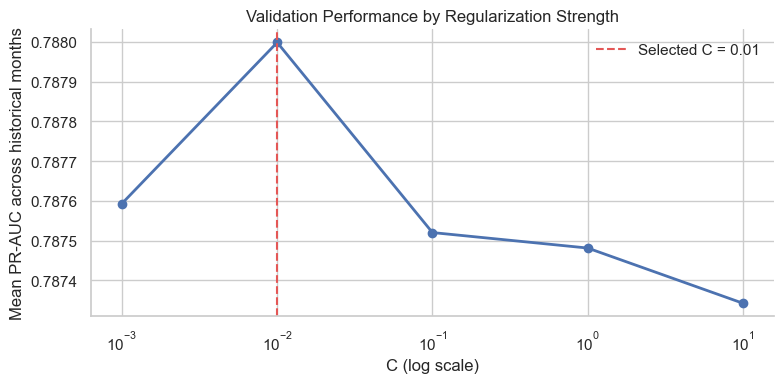

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ordered_c = c_results.sort_values('C')
ax.plot(ordered_c['C'], ordered_c['MeanPRAUC'], marker='o', linewidth=2)
ax.axvline(selected_c, color='#E45756', linestyle='--', label=f'Selected C = {selected_c:g}')
ax.set_xscale('log')
ax.set(title='Validation Performance by Regularization Strength',
       xlabel='C (log scale)', ylabel='Mean PR-AUC across historical months')
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

## 5. Select the operational probability threshold

The model outputs a probability, not an automatic business decision. The threshold decides who is flagged high risk. We choose it from validation predictions using balanced accuracy, then F1 as a tie-breaker. In production this threshold can later be adjusted to match campaign capacity and intervention cost.

In [7]:
selected_threshold, threshold_results = tune_probability_threshold(
    validation_predictions, selected_c=selected_c,
    thresholds=[0.25, 0.30, 0.35, 0.40, 0.45, 0.50,
                0.55, 0.60, 0.65, 0.70, 0.75],
)
display(threshold_results.round(4))
print(f'Selected high-risk threshold: {selected_threshold:.2f}')

,ProbabilityThreshold,PredictedHighRiskShare,Precision,Recall,F1,BalancedAccuracy,ROCAUC,PRAUC,LiftAt20Pct
0,0.40,0.5703,0.7444,0.7490,0.7467,0.7063,0.7717,0.7838,1.4562
1,0.35,0.6214,0.7272,0.7972,0.7606,0.7029,0.7717,0.7838,1.4562
2,0.45,0.5163,0.7570,0.6896,0.7217,0.7000,0.7717,0.7838,1.4562
3,0.30,0.6760,0.7094,0.8460,0.7717,0.6963,0.7717,0.7838,1.4562
4,0.50,0.4555,0.7768,0.6243,0.6922,0.6948,0.7717,0.7838,1.4562
5,0.25,0.7280,0.6914,0.8881,0.7775,0.6847,0.7717,0.7838,1.4562
6,0.55,0.3906,0.7917,0.5456,0.6460,0.6789,0.7717,0.7838,1.4562
7,0.60,0.3289,0.8087,0.4692,0.5939,0.6620,0.7717,0.7838,1.4562
8,0.65,0.2720,0.8165,0.3919,0.5296,0.6383,0.7717,0.7838,1.4562
9,0.70,0.1713,0.8339,0.2520,0.3870,0.5931,0.7717,0.7838,1.4562


Selected high-risk threshold: 0.40


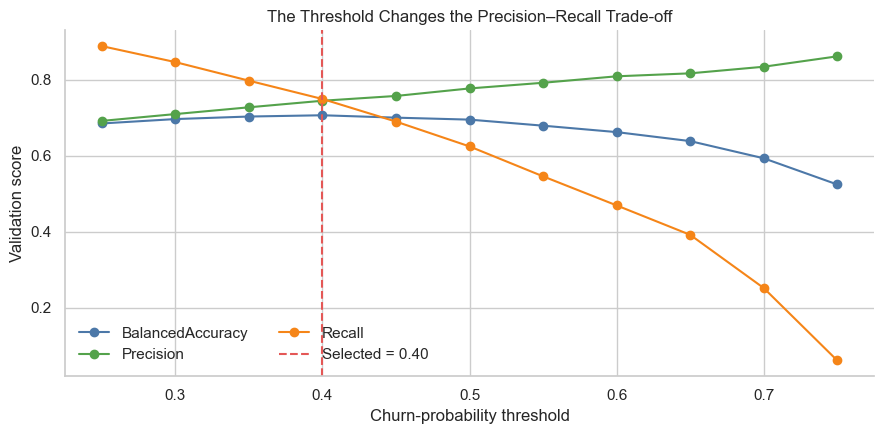

In [8]:
plot_thresholds = threshold_results.sort_values('ProbabilityThreshold')
fig, ax = plt.subplots(figsize=(9, 4.5))
for metric, color in [('BalancedAccuracy', '#4C78A8'), ('Precision', '#54A24B'), ('Recall', '#F58518')]:
    ax.plot(plot_thresholds['ProbabilityThreshold'], plot_thresholds[metric],
            marker='o', label=metric, color=color)
ax.axvline(selected_threshold, color='#E45756', linestyle='--',
           label=f'Selected = {selected_threshold:.2f}')
ax.set(title='The Threshold Changes the Precision–Recall Trade-off',
       xlabel='Churn-probability threshold', ylabel='Validation score')
ax.legend(frameon=False, ncol=2)
sns.despine()
plt.tight_layout()
plt.show()

## 6. Freeze choices and evaluate September once

Only now do we fit on all safely labelled development data and evaluate the untouched September 2011 snapshot. July and August rows are purged because their 90-day outcomes were not fully known at the September scoring date.

In [9]:
development_idx, test_idx, purged_idx = final_temporal_holdout(
    churn_data, test_date=pd.Timestamp('2011-09-01'), horizon_days=90
)
final_model = build_logistic_pipeline(
    feature_contract, regularization_c=selected_c
)
final_model.fit(
    churn_data.loc[development_idx, feature_contract.all_features],
    churn_data.loc[development_idx, 'Churn'],
)

y_test = churn_data.loc[test_idx, 'Churn']
test_probability = final_model.predict_proba(
    churn_data.loc[test_idx, feature_contract.all_features]
)[:, 1]
test_prediction = (test_probability >= selected_threshold).astype('int8')

logistic_test_metrics = baseline_metrics(y_test, test_prediction, test_probability)
logistic_test_metrics['BrierScore'] = brier_score_loss(y_test, test_probability)
logistic_test_metrics['PredictedHighRiskShare'] = test_prediction.mean()

recency_prediction = recency_rule(churn_data.loc[test_idx, 'Recency'], threshold_days=60)
recency_test_metrics = baseline_metrics(
    y_test, recency_prediction, churn_data.loc[test_idx, 'Recency']
)
comparison = pd.DataFrame({
    '60-day Recency rule': recency_test_metrics,
    'Logistic regression': logistic_test_metrics,
}).T
display(comparison.round(4))

,Precision,Recall,F1,BalancedAccuracy,ROCAUC,PRAUC,LiftAt20Pct,BrierScore,PredictedHighRiskShare
60-day Recency rule,0.5154,0.6140,0.5604,0.6199,0.6565,0.5429,1.5511,NaN,NaN
Logistic regression,0.6119,0.5882,0.5998,0.6731,0.7591,0.6473,1.8035,0.1979,0.3782


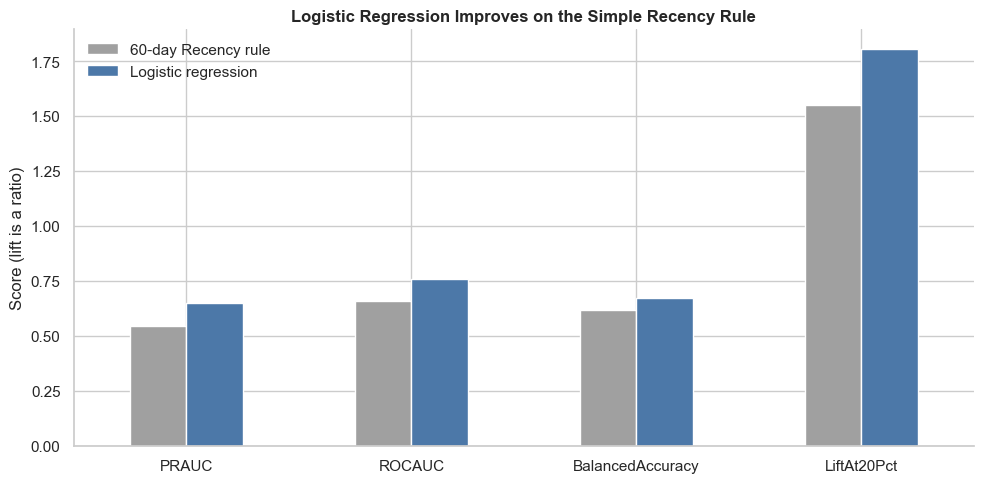

In [10]:
metrics_to_plot = ['PRAUC', 'ROCAUC', 'BalancedAccuracy', 'LiftAt20Pct']
comparison[metrics_to_plot].T.plot(
    kind='bar', figsize=(10, 5), color=['#A0A0A0', '#4C78A8'], rot=0
)
plt.title('Logistic Regression Improves on the Simple Recency Rule', weight='bold')
plt.xlabel('')
plt.ylabel('Score (lift is a ratio)')
plt.legend(title='', frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

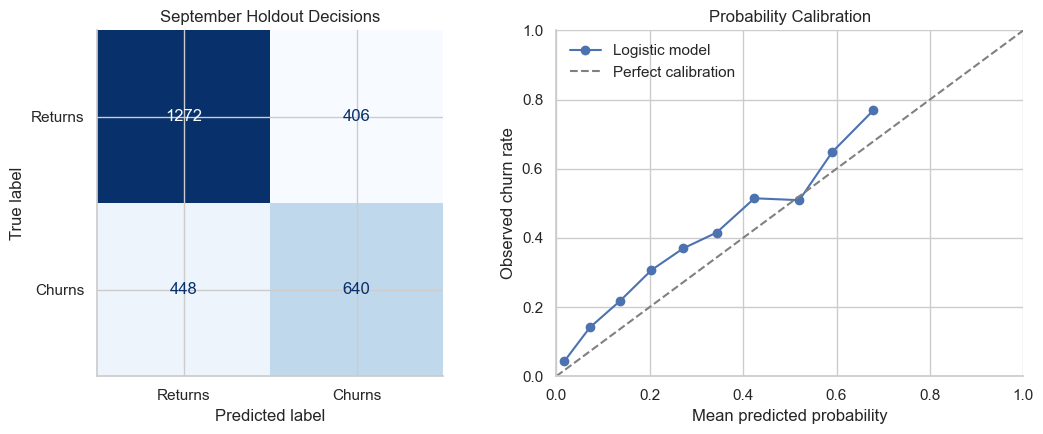

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, test_prediction, display_labels=['Returns', 'Churns'],
    cmap='Blues', colorbar=False, ax=axes[0]
)
axes[0].set_title('September Holdout Decisions')

observed, predicted = calibration_curve(y_test, test_probability, n_bins=10, strategy='quantile')
axes[1].plot(predicted, observed, marker='o', label='Logistic model')
axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
axes[1].set(title='Probability Calibration', xlabel='Mean predicted probability',
            ylabel='Observed churn rate', xlim=(0, 1), ylim=(0, 1))
axes[1].legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

## 7. Explain the model carefully

Positive coefficients are associated with higher churn risk; negative coefficients with lower risk. Because numeric features are standardized, their magnitudes are more comparable. Coefficients describe model associations—not causal effects—and correlated purchase features can share influence. Month effects may reflect dataset seasonality and should be monitored after deployment.

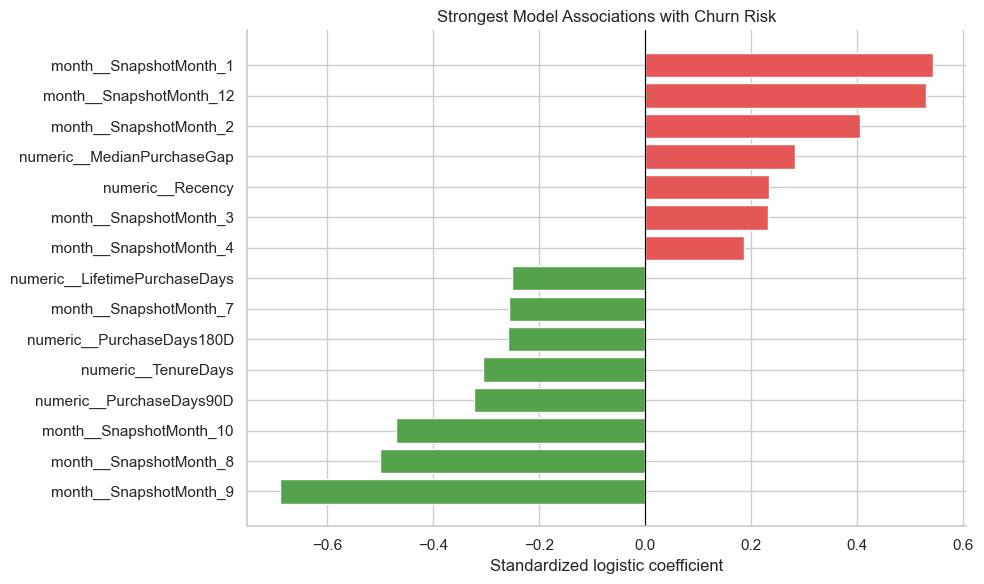

,Feature,Coefficient,AbsoluteCoefficient,Direction
0,month__SnapshotMonth_9,-0.6893,0.6893,Lower churn risk
1,month__SnapshotMonth_1,0.5424,0.5424,Higher churn risk
2,month__SnapshotMonth_12,0.5297,0.5297,Higher churn risk
3,month__SnapshotMonth_8,-0.4997,0.4997,Lower churn risk
4,month__SnapshotMonth_10,-0.4707,0.4707,Lower churn risk
5,month__SnapshotMonth_2,0.4053,0.4053,Higher churn risk
6,numeric__PurchaseDays90D,-0.3226,0.3226,Lower churn risk
7,numeric__TenureDays,-0.3062,0.3062,Lower churn risk
8,numeric__MedianPurchaseGap,0.2827,0.2827,Higher churn risk
9,numeric__PurchaseDays180D,-0.2580,0.2580,Lower churn risk


In [12]:
top_coefficients = coefficient_table(final_model, top_n=15).sort_values('Coefficient')
colors = np.where(top_coefficients['Coefficient'] >= 0, '#E45756', '#54A24B')
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_coefficients['Feature'], top_coefficients['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set(title='Strongest Model Associations with Churn Risk',
       xlabel='Standardized logistic coefficient', ylabel='')
sns.despine()
plt.tight_layout()
plt.show()
display(top_coefficients.sort_values('AbsoluteCoefficient', ascending=False).round(4))

## Stakeholder conclusion

The logistic model ranks future churners materially better than the simple 60-day inactivity rule. On the untouched September snapshot, PR-AUC improved from about **0.543 to 0.647**, balanced accuracy from **0.620 to 0.673**, and lift among the highest-risk 20% from **1.55× to 1.80×**.

This means a retention team targeting the model's top-risk customers would reach a group with roughly **1.8 times the normal churn rate**. The result is a credible interpretable benchmark, not yet the final deployed model. Next, compare tree-based models using the same folds, untouched holdout, lift, calibration, and campaign-capacity criteria.